# 🏠 House Price Prediction - Exploratory Data Analysis

This notebook provides comprehensive EDA for the Vietnamese house price dataset.

## Add thư viện

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import io

## 1. Load Data

In [5]:
# Load raw data
df = pd.read_csv('../data/raw/house_data_hcm.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

Dataset shape: (40000, 17)

Columns: ['Address', 'Area', 'Frontage', 'Access Road', 'House direction', 'Balcony direction', 'Floors', 'Bedrooms', 'Bathrooms', 'Legal status', 'Furniture state', 'Price', 'Property_Type', 'City', 'District', 'Land_Price_Per_M2', 'Land_Value']


In [6]:

df.head()

,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price,Property_Type,City,District,Land_Price_Per_M2,Land_Value
0,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,4.085,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Sale contract,Full,5.35,Nhà,Hồ Chí Minh,Quận Gò Vấp,500.0,27.00
1,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,4.085,5.0,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90,Nhà,Hồ Chí Minh,Quận Gò Vấp,70.0,6.44
2,"Đường Phạm Văn Chiêu, Phường 14, Gò Vấp, Hồ Ch...",30.0,4.085,5.0,Đông - Nam,Đông - Nam,2.0,2.0,2.0,Have certificate,Full,3.79,Nhà,Hồ Chí Minh,Quận Gò Vấp,500.0,15.00
3,"Đường Quang Trung, Phường 12, Gò Vấp, Hồ Chí Minh",46.0,4.600,6.0,Đông - Nam,Đông - Nam,4.0,4.0,5.0,Sale contract,Full,7.99,Nhà,Hồ Chí Minh,Quận Gò Vấp,500.0,23.00
4,"Đường Ngô Tất Tố, Phường 22, Bình Thạnh, Hồ Ch...",60.0,3.500,5.0,Đông - Nam,Đông,2.0,6.0,5.0,Have certificate,Full,5.60,Nhà,Hồ Chí Minh,Quận Bình Thạnh,130.0,7.80


## 2. Data Overview

In [7]:
## Kiểu dữ liệu và thông tin của data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Address            40000 non-null  object 
 1   Area               40000 non-null  float64
 2   Frontage           40000 non-null  float64
 3   Access Road        40000 non-null  float64
 4   House direction    40000 non-null  object 
 5   Balcony direction  40000 non-null  object 
 6   Floors             40000 non-null  float64
 7   Bedrooms           40000 non-null  float64
 8   Bathrooms          40000 non-null  float64
 9   Legal status       40000 non-null  object 
 10  Furniture state    40000 non-null  object 
 11  Price              40000 non-null  float64
 12  Property_Type      40000 non-null  object 
 13  City               40000 non-null  object 
 14  District           40000 non-null  object 
 15  Land_Price_Per_M2  40000 non-null  float64
 16  Land_Value         400

In [8]:
## mô tả cột số
df.describe()

,Area,Frontage,Access Road,Floors,Bedrooms,Bathrooms,Price,Land_Price_Per_M2,Land_Value
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,74.430544,7.205004,6.165999,2.539287,3.190575,2.860250,16.530003,223.542675,15.995007
std,55.169876,3.447606,2.994899,1.174871,1.498153,1.389107,25.001494,176.956616,18.052687
min,10.000000,2.000000,1.000000,1.000000,1.000000,1.000000,0.542774,10.000000,0.360000
25%,37.400000,4.200000,4.400000,2.000000,2.000000,2.000000,5.200000,87.000000,4.700000
50%,60.000000,6.000000,6.000000,2.000000,3.000000,3.000000,8.400000,144.000000,9.309300
75%,96.000000,9.645963,7.700000,3.000000,4.000000,4.000000,16.910000,366.000000,20.150000
max,500.000000,20.000000,50.000000,7.000000,10.000000,10.000000,541.548644,750.000000,250.000000


In [9]:
## phân loại cột
df.describe(include='object')

,Address,House direction,Balcony direction,Legal status,Furniture state,Property_Type,City,District
count,40000,40000,40000,40000,40000,40000,40000,40000
unique,26034,8,8,4,3,2,1,24
top,"Đường Huỳnh Tấn Phát, Thị trấn Nhà Bè, Nhà Bè,...",Đông - Nam,Đông - Nam,Have certificate,Full,Nhà,Hồ Chí Minh,Quận Bình Tân
freq,94,16736,18784,22034,21990,28324,40000,3386


## 3. Giá trị thiếu

In [10]:
# Missing values summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %


C:\Users\Admin\AppData\Local\Temp\ipykernel_1856\4173317996.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=missing_df, x=missing_df.index, y='Missing %', palette='Reds_r', ax=ax)


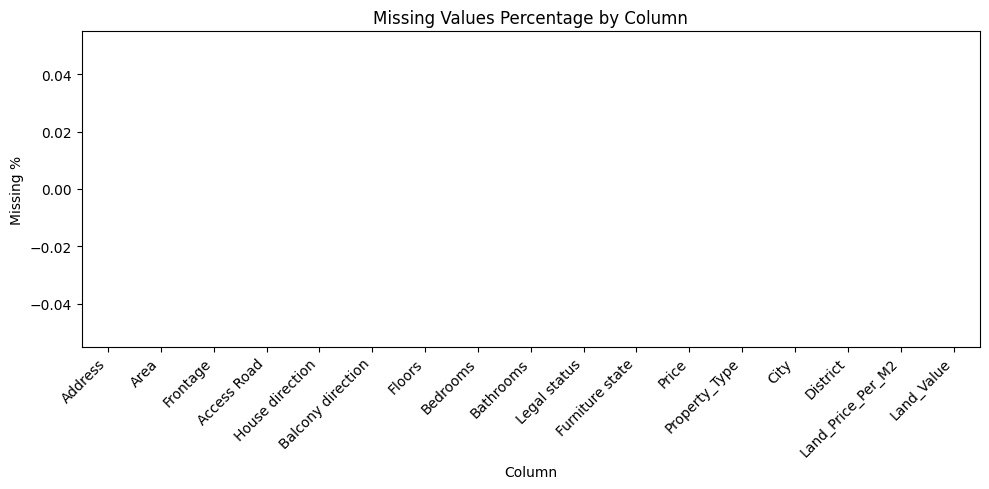

In [11]:
# biẻu đồ giá trị thiếu
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=missing_df, x=missing_df.index, y='Missing %', palette='Reds_r', ax=ax)
plt.xticks(rotation=45, ha='right')
plt.title('Missing Values Percentage by Column')
plt.ylabel('Missing %')
plt.xlabel('Column')
plt.tight_layout()
plt.show()

## 4.Mục tiêu => Price

In [12]:
print("Thống kê giá nhà (tỷ VNĐ):")
print(df['Price'].describe())


Thống kê giá nhà (tỷ VNĐ):
count    40000.000000
mean        16.530003
std         25.001494
min          0.542774
25%          5.200000
50%          8.400000
75%         16.910000
max        541.548644
Name: Price, dtype: float64


In [13]:
## độ lệch 
print(f"\nSkewness: {df['Price'].skew():.4f}")
print(f"Kurtosis: {df['Price'].kurtosis():.4f}")


Skewness: 5.5956
Kurtosis: 54.5509


Độ lệch thấp kèm độ dày thấp => ít outlier, lệch không qáu nhiều với price

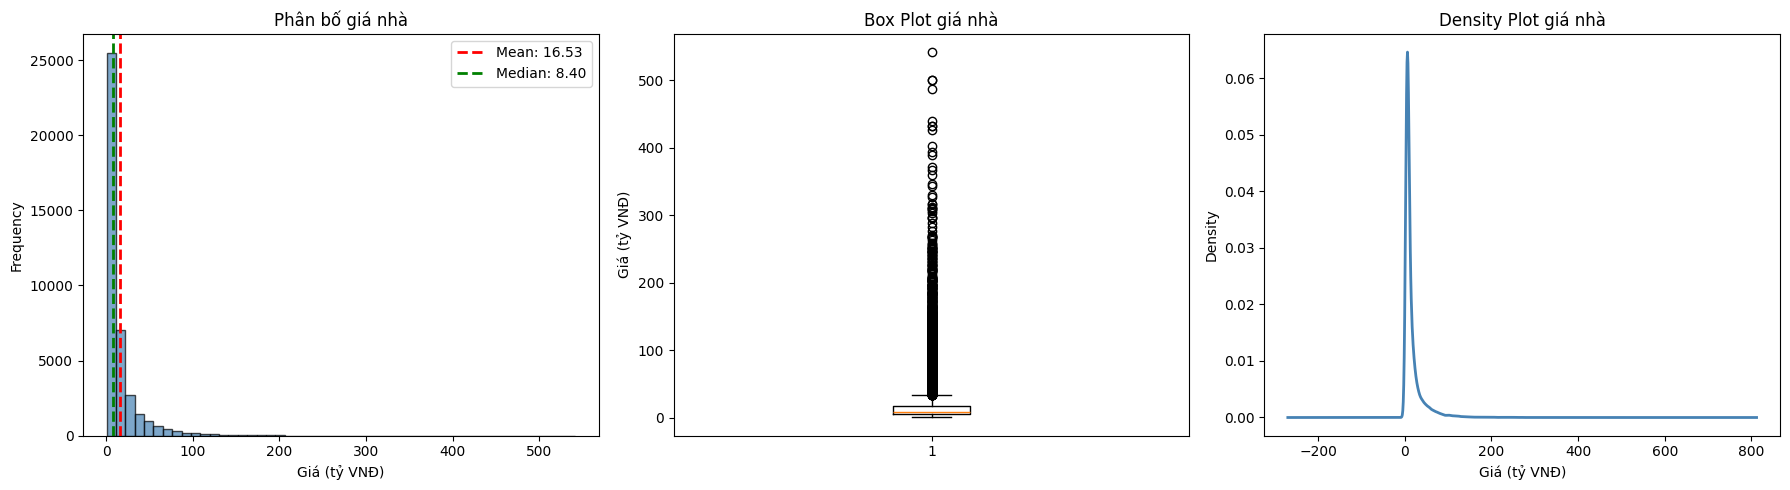

In [14]:
## Tạo biểu đồ 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df['Price'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(df['Price'].mean(), color='red', linestyle='--', linewidth=2,
                label=f"Mean: {df['Price'].mean():.2f}")
axes[0].axvline(df['Price'].median(), color='green', linestyle='--', linewidth=2,
                label=f"Median: {df['Price'].median():.2f}")
axes[0].set_xlabel('Giá (tỷ VNĐ)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Phân bố giá nhà')
axes[0].legend()

# Box plot
axes[1].boxplot(df['Price'].dropna(), vert=True)
axes[1].set_ylabel('Giá (tỷ VNĐ)')
axes[1].set_title('Box Plot giá nhà')

# KDE plot
df['Price'].plot.kde(ax=axes[2], color='steelblue', linewidth=2)
axes[2].set_xlabel('Giá (tỷ VNĐ)')
axes[2].set_title('Density Plot giá nhà')

plt.tight_layout()
plt.show()

In [15]:
## Khoảng phân bố Price
price_ranges = [(0, 2), (2, 4), (4, 6), (6, 8), (8, 10), (10, 12)]
print("=== Phân bố giá theo khoảng ===")
for low, high in price_ranges:
    count = len(df[(df['Price'] >= low) & (df['Price'] < high)])
    pct = count / len(df) * 100
    bar = '█' * int(pct)
    print(f"  {low:>2}-{high:<2} tỷ: {count:>6,} ({pct:>5.1f}%) {bar}")

=== Phân bố giá theo khoảng ===
   0-2  tỷ:    893 (  2.2%) ██
   2-4  tỷ:  5,013 ( 12.5%) ████████████
   4-6  tỷ:  6,766 ( 16.9%) ████████████████
   6-8  tỷ:  6,372 ( 15.9%) ███████████████
   8-10 tỷ:  4,758 ( 11.9%) ███████████
  10-12 tỷ:  2,329 (  5.8%) █████


## 5. Các đặc trưng số

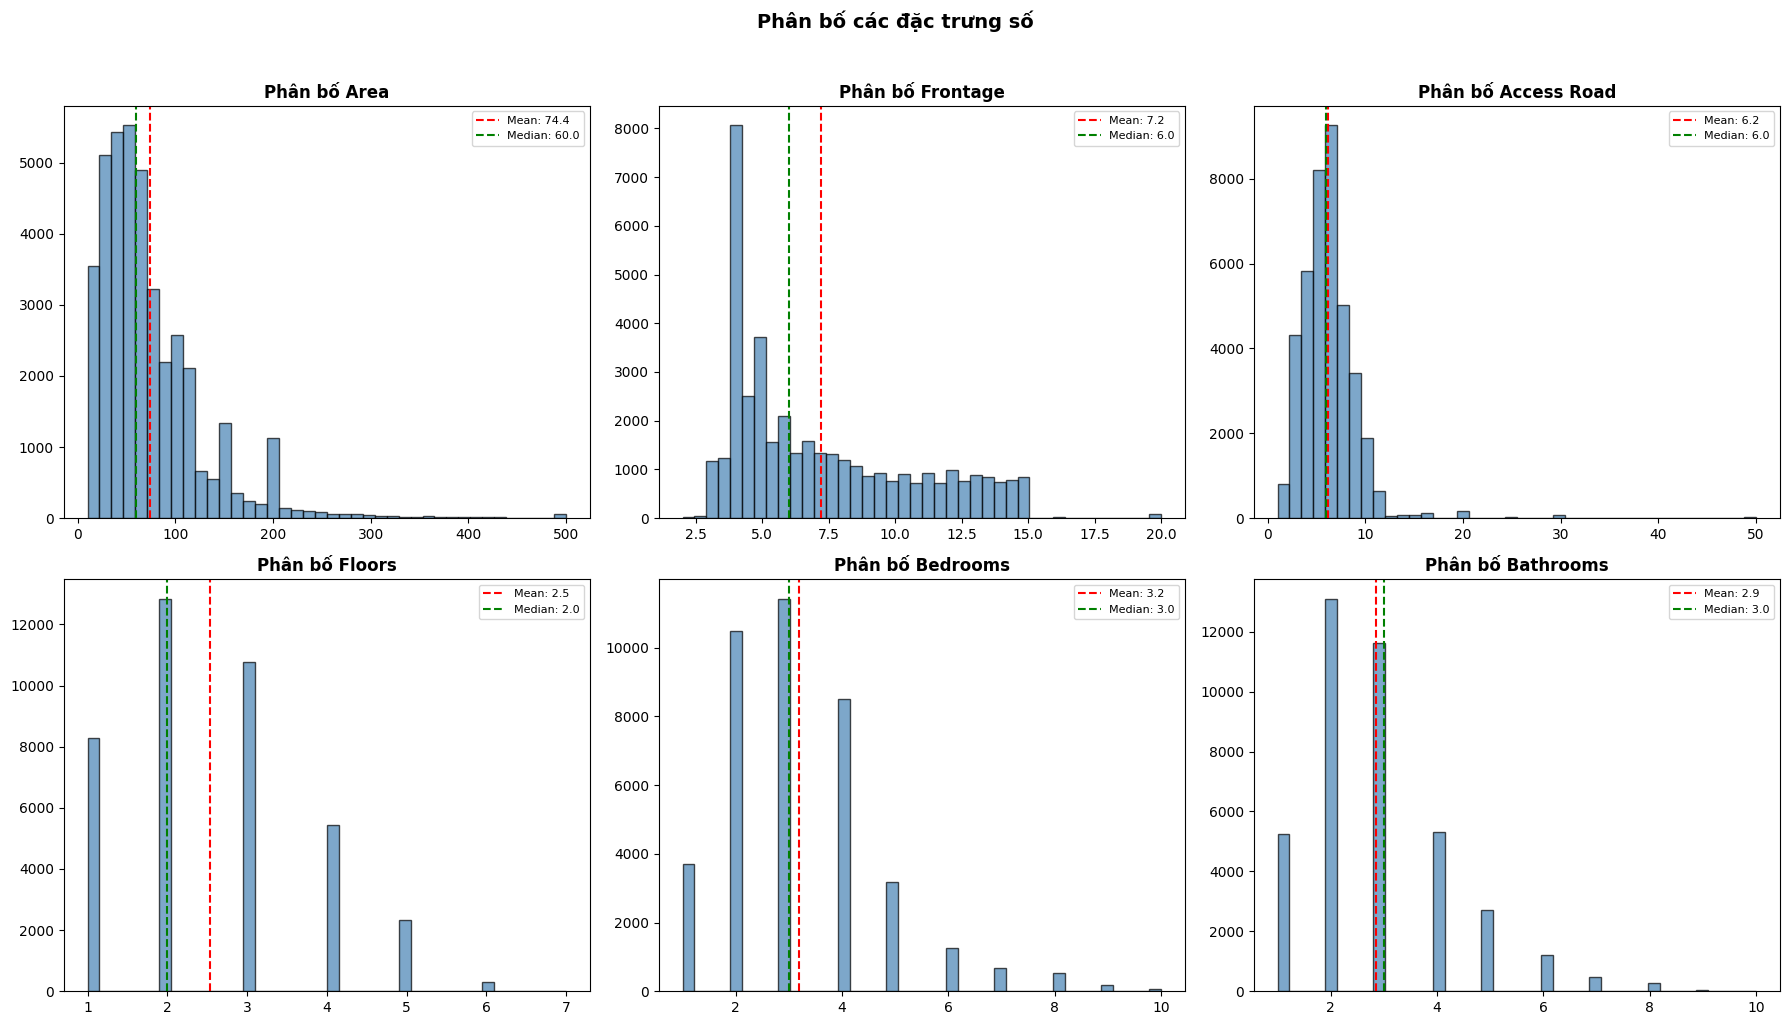

In [16]:
numeric_cols = ['Area', 'Frontage', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.1f}')
    axes[i].axvline(data.median(), color='green', linestyle='--', label=f'Median: {data.median():.1f}')
    axes[i].set_title(f'Phân bố {col}', fontsize=12, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Phân bố các đặc trưng số', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Phân tích các đặc trưng phân loại (Categorical Features)

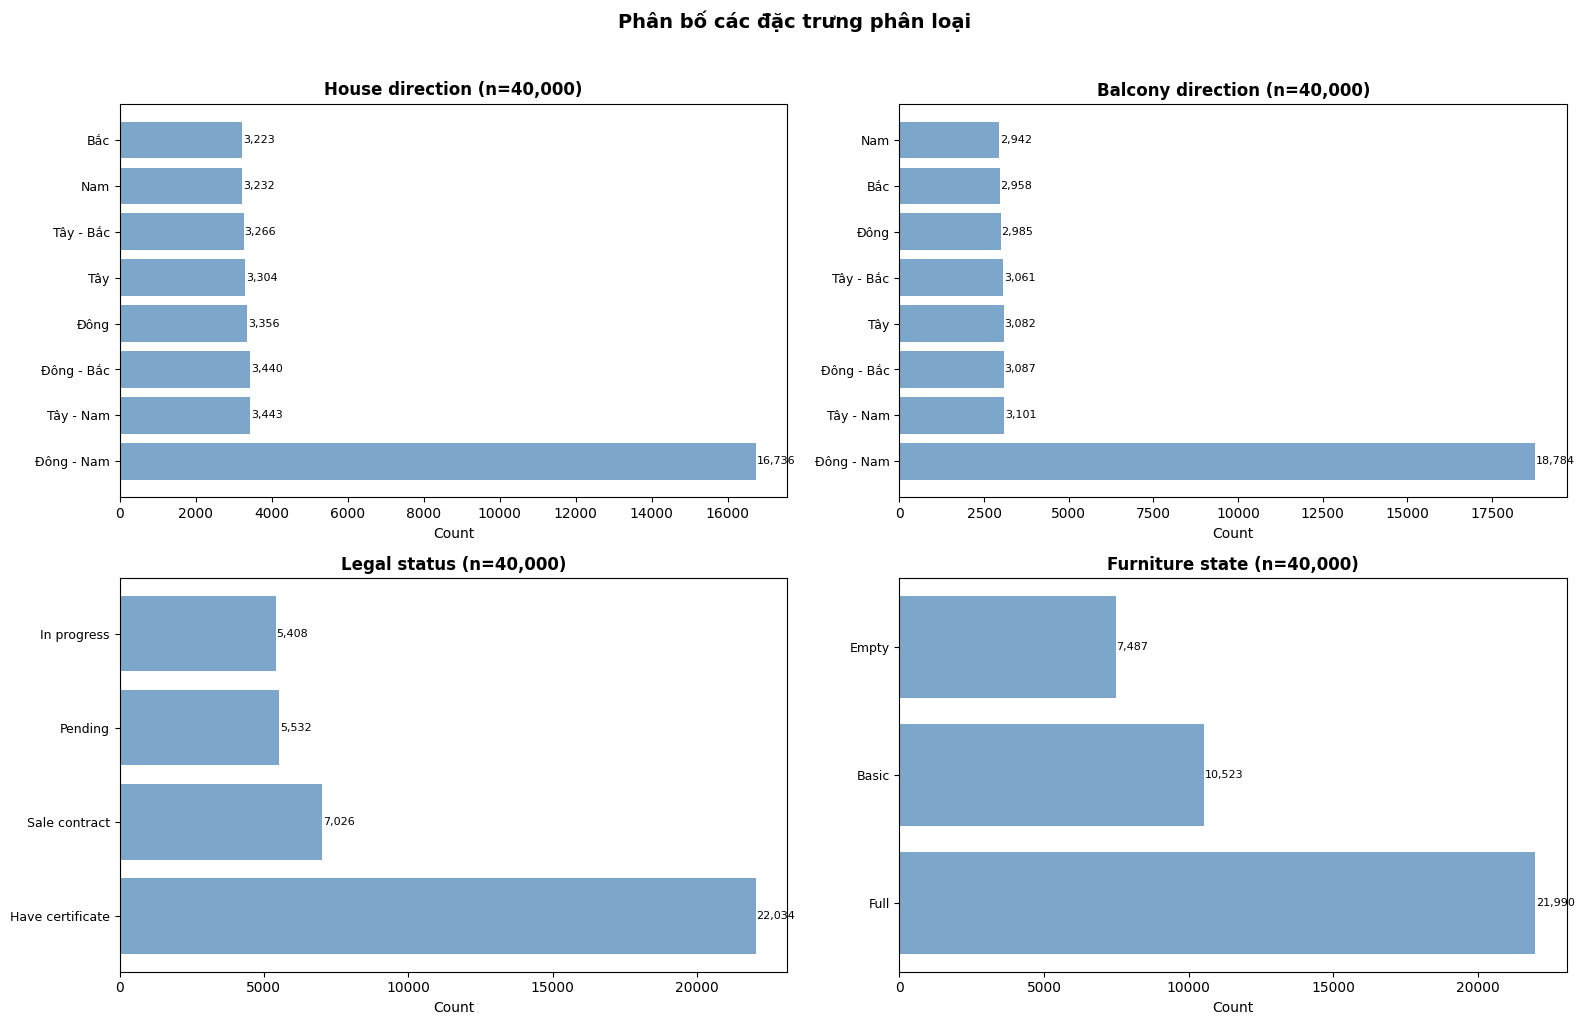

In [17]:
cat_cols = ['House direction', 'Balcony direction', 'Legal status', 'Furniture state']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    bars = axes[i].barh(range(len(counts)), counts.values, color='steelblue', alpha=0.7)
    axes[i].set_yticks(range(len(counts)))
    axes[i].set_yticklabels(counts.index, fontsize=9)
    axes[i].set_title(f'{col} (n={counts.sum():,})', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Count')
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                     f'{val:,}', va='center', fontsize=8)

plt.suptitle('Phân bố các đặc trưng phân loại', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Ma trận tương quan (Correlation Matrix)

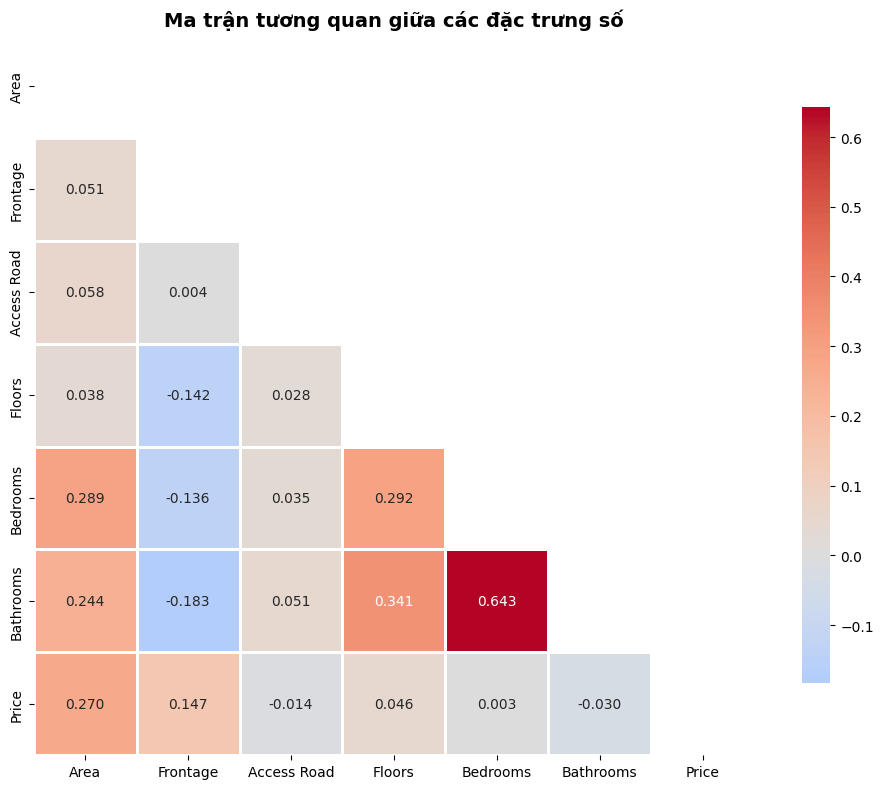

In [18]:
corr_cols = ['Area', 'Frontage', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms', 'Price']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=1, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Ma trận tương quan giữa các đặc trưng số', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
## Tương quan với price
print("=== Tương quan với giá nhà (Price) ===")
price_corr = corr_matrix['Price'].drop('Price').sort_values(ascending=False)
for feat, val in price_corr.items():
    bar = '█' * int(abs(val) * 50)
    sign = '+' if val > 0 else '-'
    print(f"  {feat:<20} {val:>+.4f}  {bar}")

=== Tương quan với giá nhà (Price) ===
  Area                 +0.2699  █████████████
  Frontage             +0.1471  ███████
  Floors               +0.0462  ██
  Bedrooms             +0.0026  
  Access Road          -0.0140  
  Bathrooms            -0.0298  █


## 8. Scatter Plots: Features vs Price

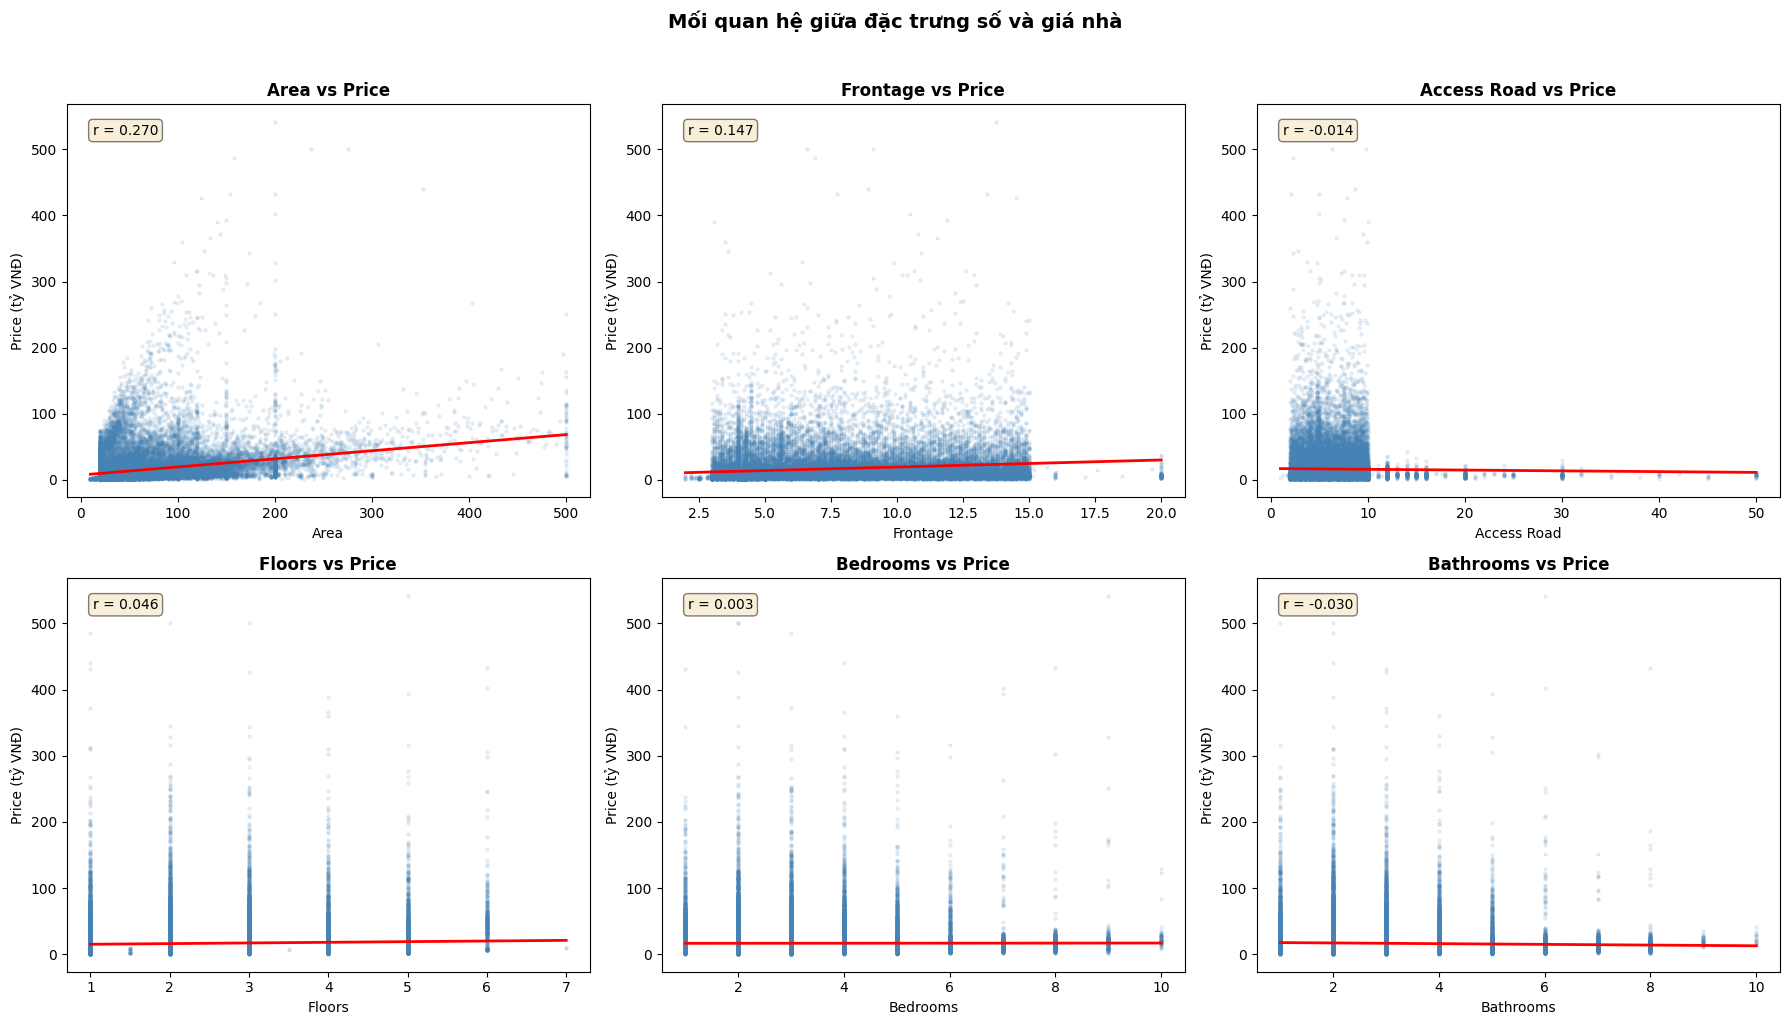

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data = df[[col, 'Price']].dropna()
    axes[i].scatter(data[col], data['Price'], alpha=0.1, s=5, color='steelblue')
    # Fit line
    z = np.polyfit(data[col], data['Price'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(data[col].min(), data[col].max(), 100)
    axes[i].plot(x_line, p(x_line), 'r-', linewidth=2, label=f'Trend')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Price (tỷ VNĐ)')
    axes[i].set_title(f'{col} vs Price', fontsize=12, fontweight='bold')
    corr_val = data[col].corr(data['Price'])
    axes[i].text(0.05, 0.95, f'r = {corr_val:.3f}', transform=axes[i].transAxes,
                 fontsize=10, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Mối quan hệ giữa đặc trưng số và giá nhà', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 9. Giá nhà theo đặc trưng phân loại

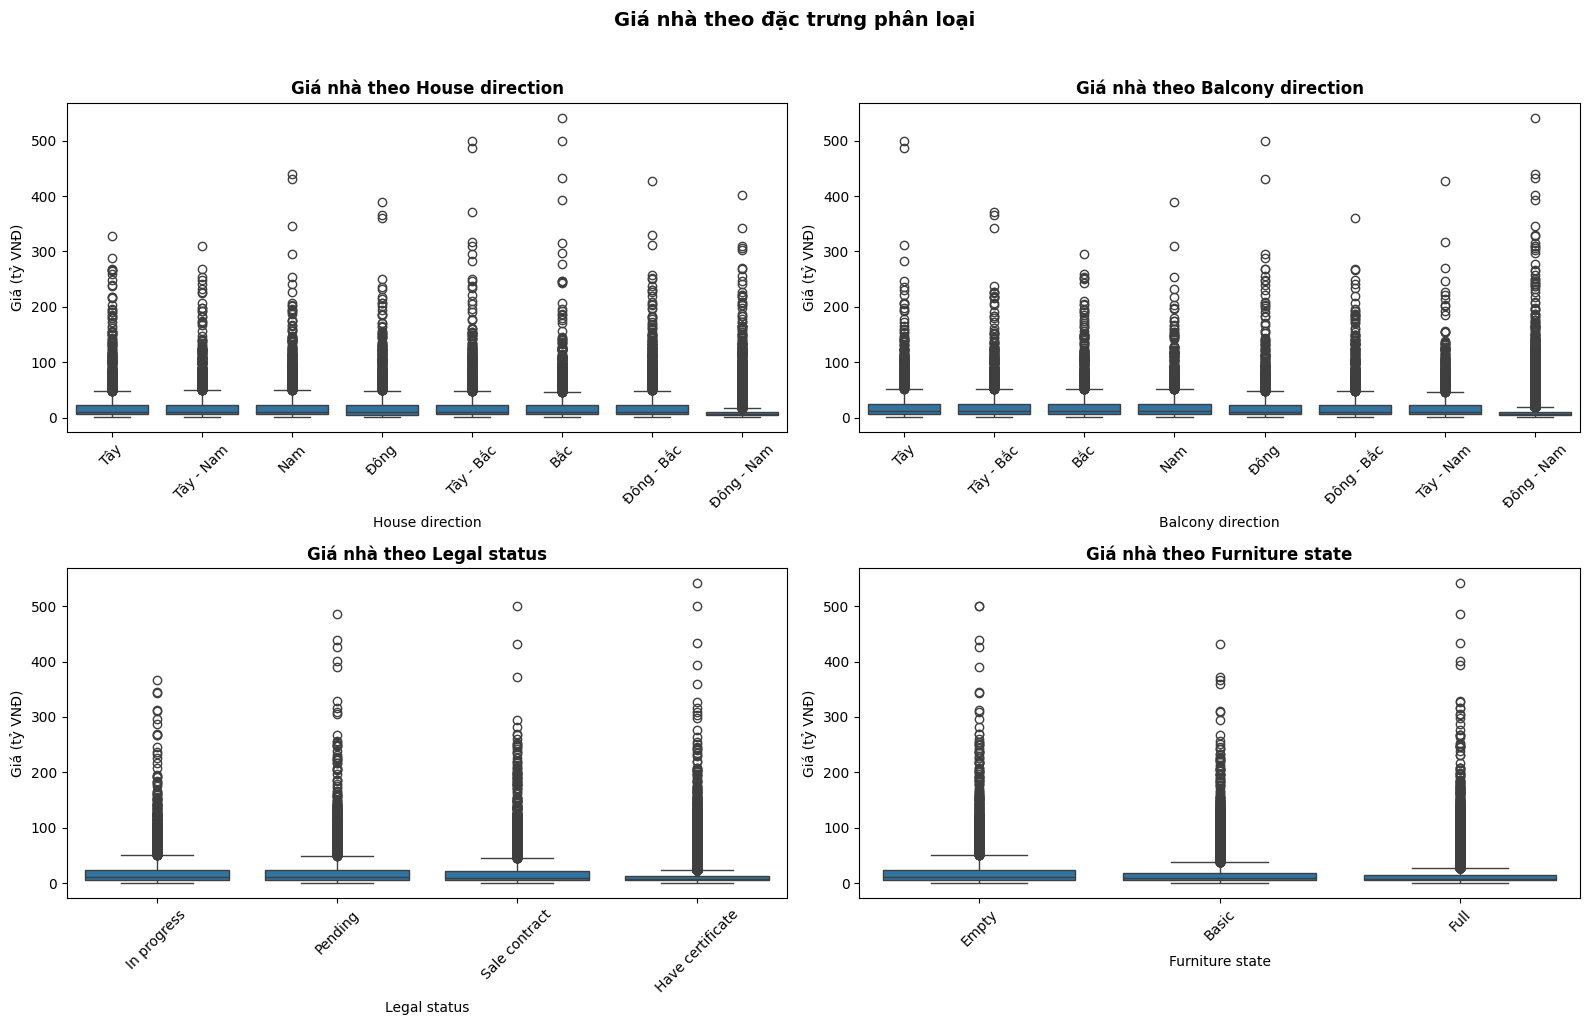

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    data = df[[col, 'Price']].dropna()
    order = data.groupby(col)['Price'].median().sort_values(ascending=False).index
    sns.boxplot(data=data, x=col, y='Price', order=order, ax=axes[i])
    axes[i].set_title(f'Giá nhà theo {col}', fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Giá (tỷ VNĐ)')

plt.suptitle('Giá nhà theo đặc trưng phân loại', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Phân tích theo khu vực (District / City)

In [22]:
# Trích xuất District và City từ Address
df_loc = df.copy()
df_loc['Address'] = df_loc['Address'].fillna('Unknown')
parts = df_loc['Address'].str.split(',')
df_loc['City'] = parts.str[-1].str.strip()
df_loc['District'] = parts.str[-2].str.strip()

# Xử lý trường hợp split thất bại
mask = df_loc['District'].isna() | (df_loc['District'] == df_loc['Address'])
df_loc.loc[mask, 'District'] = 'Unknown'
df_loc.loc[mask, 'City'] = 'Unknown'

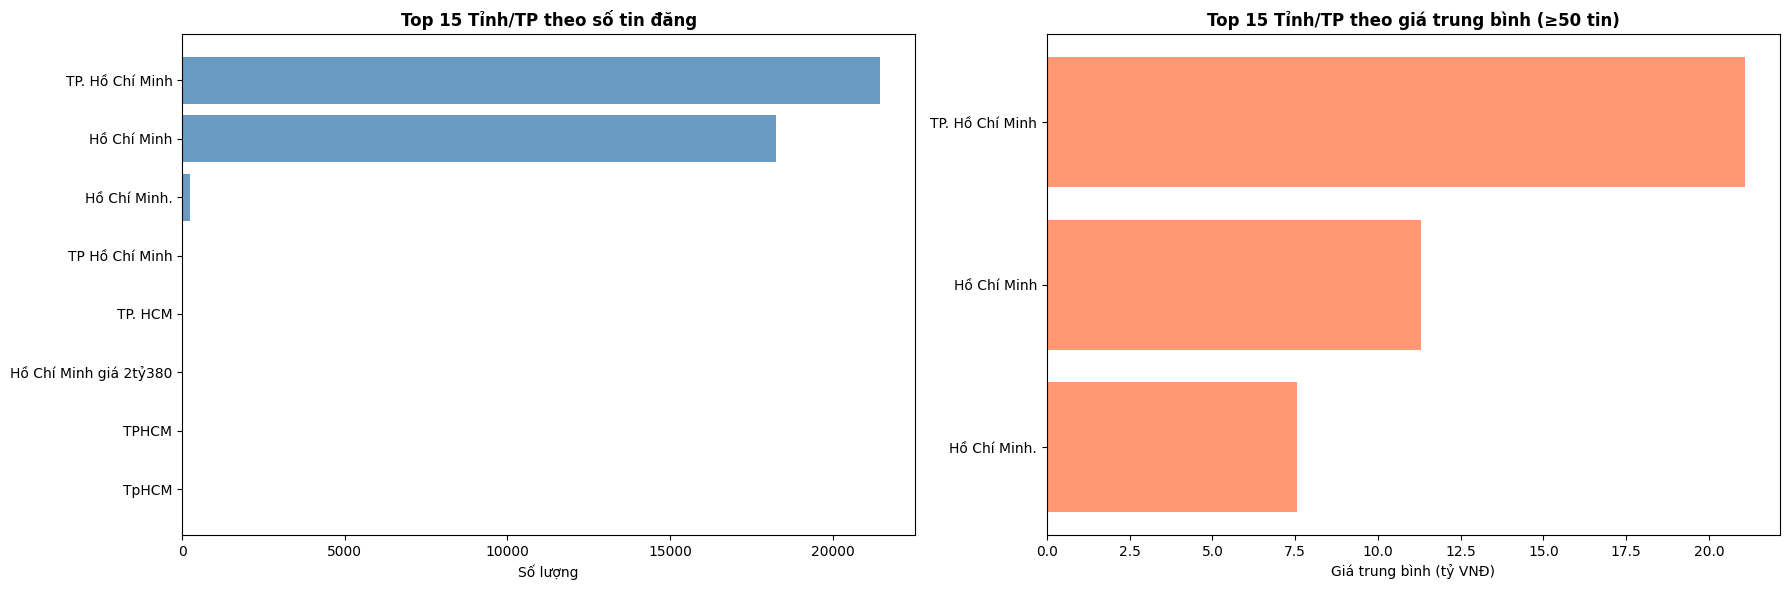

In [23]:
# Top 15 thành phố theo số lượng tin đăng
city_counts = df_loc['City'].value_counts().head(15)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh(range(len(city_counts)), city_counts.values, color='steelblue', alpha=0.8)
axes[0].set_yticks(range(len(city_counts)))
axes[0].set_yticklabels(city_counts.index)
axes[0].set_title('Top 15 Tỉnh/TP theo số tin đăng', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Số lượng')
axes[0].invert_yaxis()
# Giá trung bình theo top 15 city
city_price = df_loc.groupby('City')['Price'].agg(['mean', 'count'])
city_price = city_price[city_price['count'] >= 50].sort_values('mean', ascending=False).head(15)
axes[1].barh(range(len(city_price)), city_price['mean'].values, color='coral', alpha=0.8)
axes[1].set_yticks(range(len(city_price)))
axes[1].set_yticklabels(city_price.index)
axes[1].set_title('Top 15 Tỉnh/TP theo giá trung bình (≥50 tin)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Giá trung bình (tỷ VNĐ)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


In [24]:
# Top 5 Quận/Huyện theo giá trung bình
district_stats = df_loc.groupby(['District', 'City'])['Price'].agg(['mean', 'median', 'count', 'std'])
district_stats = district_stats[district_stats['count'] >= 30].sort_values('mean', ascending=False)

print("=== Top 5 Quận/Huyện đắt nhất (≥30 tin đăng) ===")
top_districts = district_stats.head(5)
for (district, city), row in top_districts.iterrows():
    print(f"  {district}, {city}: "
          f"TB={row['mean']:.2f} tỷ | "
          f"Trung vị={row['median']:.2f} tỷ | "
          f"n={int(row['count'])}")

=== Top 5 Quận/Huyện đắt nhất (≥30 tin đăng) ===
  Quận 1, TP. Hồ Chí Minh: TB=81.73 tỷ | Trung vị=64.80 tỷ | n=1711
  Quận 2 (Thủ Đức), Hồ Chí Minh: TB=63.43 tỷ | Trung vị=57.68 tỷ | n=125
  Quận 1, Hồ Chí Minh: TB=54.14 tỷ | Trung vị=15.73 tỷ | n=273
  Quận 9 (Thủ Đức), Hồ Chí Minh: TB=46.54 tỷ | Trung vị=44.75 tỷ | n=116
  Quận 3, TP. Hồ Chí Minh: TB=30.87 tỷ | Trung vị=24.15 tỷ | n=1700


## 11. Phân tích Outlier

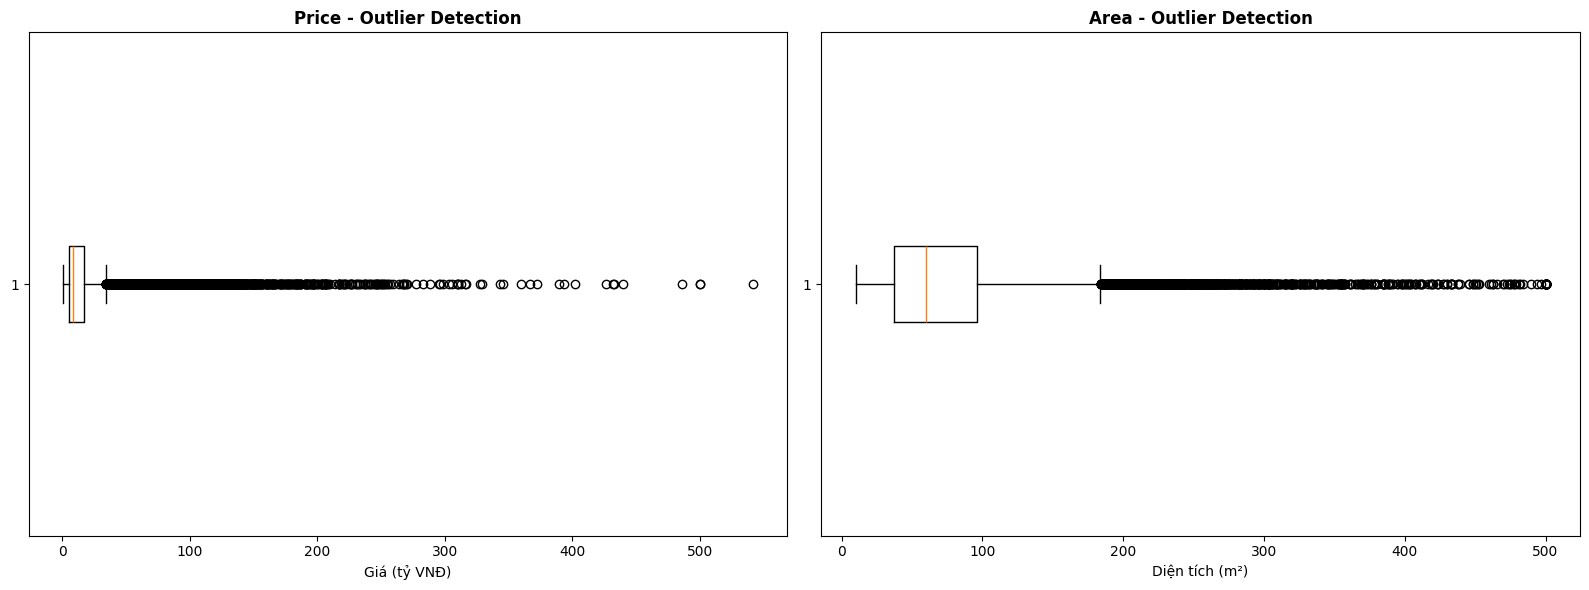

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Price outliers
axes[0].boxplot(df['Price'].dropna(), vert=False)
axes[0].set_title('Price - Outlier Detection', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Giá (tỷ VNĐ)')

# Area outliers
axes[1].boxplot(df['Area'].dropna(), vert=False)
axes[1].set_title('Area - Outlier Detection', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Diện tích (m²)')

plt.tight_layout()
plt.show()


In [26]:
# Thống kê outlier bằng IQR method
print("=== Phân tích Outlier (IQR method) ===")
for col in ['Price', 'Area', 'Frontage', 'Access Road']:
    data = df[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data < lower) | (data > upper)]
    print(f"\n  {col}:")
    print(f"    Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"    Range: [{lower:.2f}, {upper:.2f}]")
    print(f"    Outliers: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)")

=== Phân tích Outlier (IQR method) ===

  Price:
    Q1=5.20, Q3=16.91, IQR=11.71
    Range: [-12.37, 34.48]
    Outliers: 4481 (11.2%)

  Area:
    Q1=37.40, Q3=96.00, IQR=58.60
    Range: [-50.50, 183.90]
    Outliers: 2191 (5.5%)

  Frontage:
    Q1=4.20, Q3=9.65, IQR=5.45
    Range: [-3.97, 17.81]
    Outliers: 78 (0.2%)

  Access Road:
    Q1=4.40, Q3=7.70, IQR=3.30
    Range: [-0.55, 12.65]
    Outliers: 638 (1.6%)


## 12. Phân tích sau khi loại bỏ Outlier

In [27]:
## Loại bỏ outlier cực đoan (giống train.py)
PRICE_MAX = 20.0   # tỷ VNĐ
AREA_MAX = 500.0   # m²

df_clean = df.copy()
n_before = len(df_clean)
df_clean = df_clean[df_clean['Price'] <= PRICE_MAX]
df_clean = df_clean[df_clean['Area'] <= AREA_MAX]
df_clean = df_clean[df_clean['Price'] > 0]
n_after = len(df_clean)

print(f"Trước khi lọc: {n_before:,} rows")
print(f"Sau khi lọc:   {n_after:,} rows")
print(f"Đã loại bỏ:    {n_before - n_after:,} rows ({(n_before - n_after)/n_before*100:.1f}%)")


Trước khi lọc: 40,000 rows
Sau khi lọc:   31,611 rows
Đã loại bỏ:    8,389 rows (21.0%)


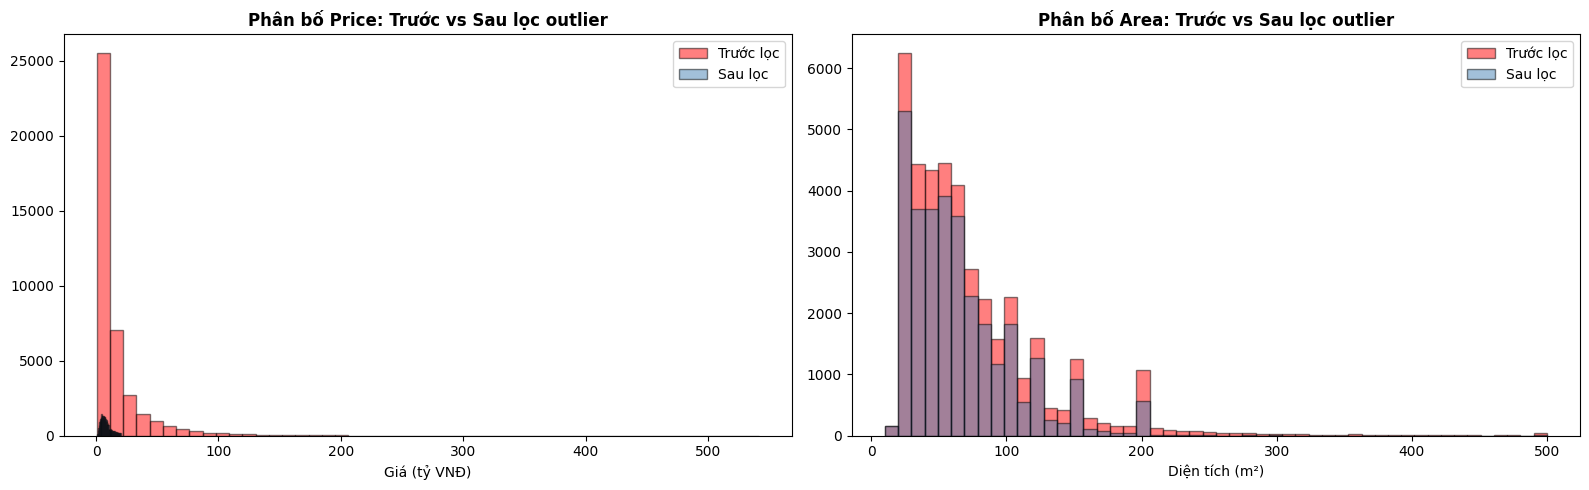

In [28]:
# So sánh phân bố trước/sau lọc
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df['Price'], bins=50, alpha=0.5, label='Trước lọc', color='red', edgecolor='black')
axes[0].hist(df_clean['Price'], bins=50, alpha=0.5, label='Sau lọc', color='steelblue', edgecolor='black')
axes[0].set_title('Phân bố Price: Trước vs Sau lọc outlier', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Giá (tỷ VNĐ)')
axes[0].legend()

axes[1].hist(df['Area'], bins=50, alpha=0.5, label='Trước lọc', color='red', edgecolor='black')
axes[1].hist(df_clean['Area'], bins=50, alpha=0.5, label='Sau lọc', color='steelblue', edgecolor='black')
axes[1].set_title('Phân bố Area: Trước vs Sau lọc outlier', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Diện tích (m²)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 13. Pair Plot (các feature quan trọng)


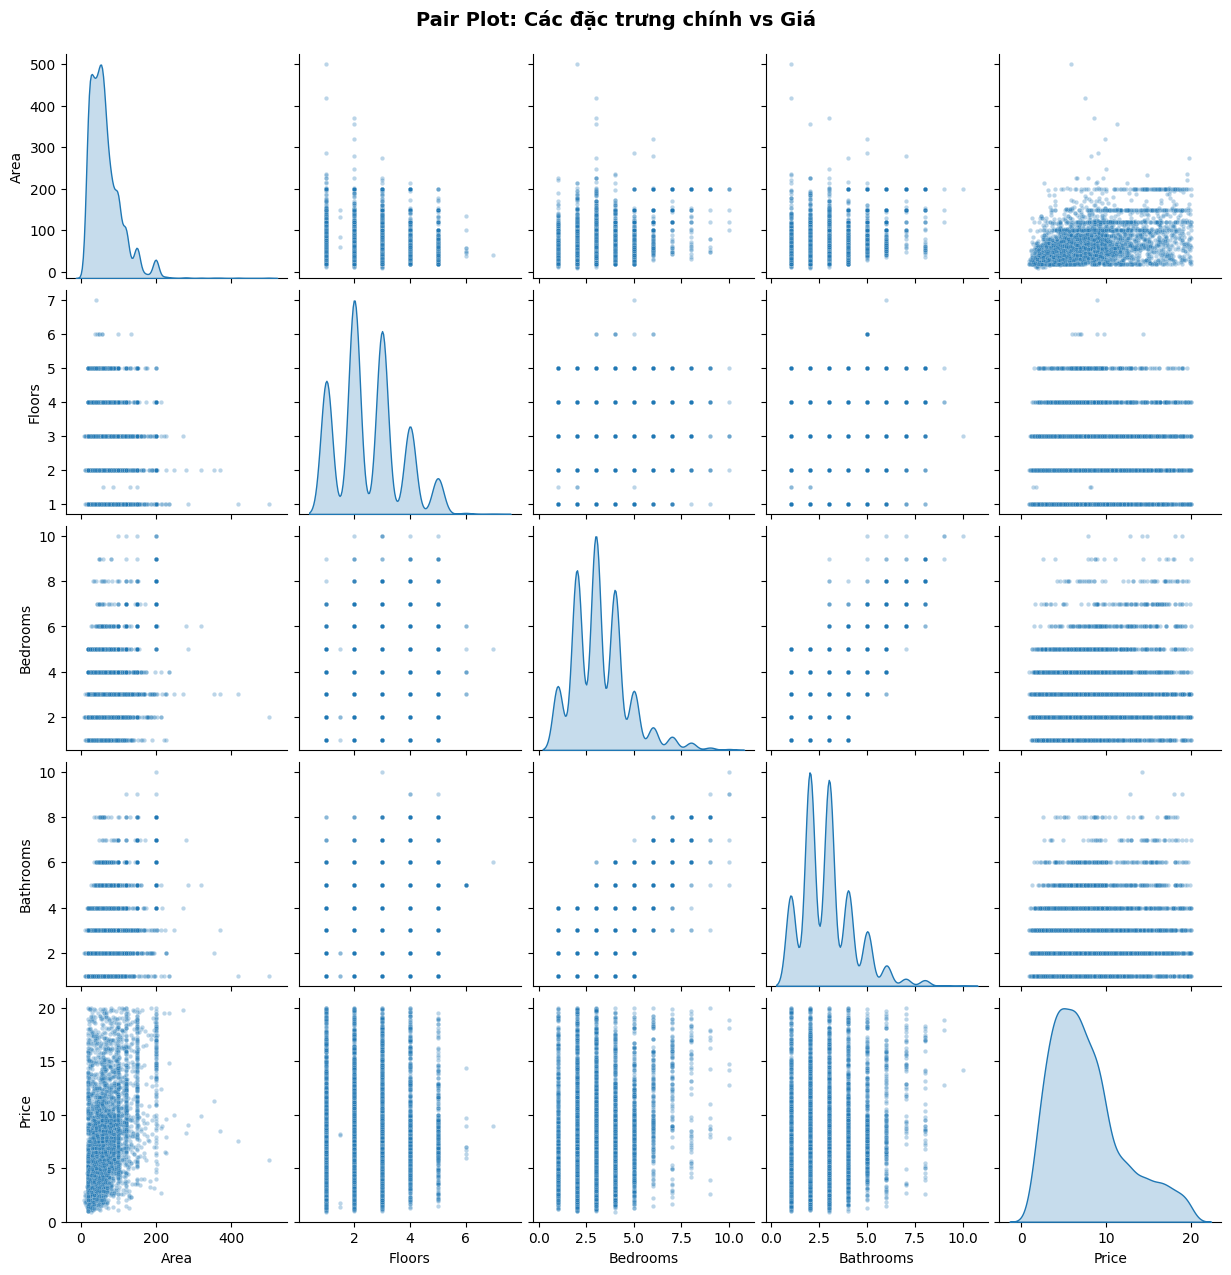

In [29]:
# Pair plot cho top features vs Price (sample để tránh chậm)
sample_df = df_clean[['Area', 'Floors', 'Bedrooms', 'Bathrooms', 'Price']].dropna()
if len(sample_df) > 5000:
    sample_df = sample_df.sample(n=5000, random_state=42)

g = sns.pairplot(sample_df, diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10})
g.figure.suptitle('Pair Plot: Các đặc trưng chính vs Giá', fontsize=14, fontweight='bold', y=1.02)
plt.show()